# 03b-05 - Dense Matching

You see how the software found a height for nearly every pixel, and run that search yourself for two pixels.

We begin with the dense cloud of the whole flight. Then we pick a roof point and a lawn point, find their pixels in one photograph, and walk along each ray to see where the second photograph agrees. We open the software's depth map, and end in the fused cloud of the window.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm
from matplotlib.colors import ListedColormap

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## The dense cloud of the whole flight

The cell loads a sample of the flight's dense cloud and draws it twice, in the points' own colours and by the class the software gave each point.

100,000 points drawn   reference 100,000
12,713,513 points in the whole cloud   reference 12,713,513
{1: 'unclassified', 2: 'ground', 3: 'low vegetation', 6: 'building'}


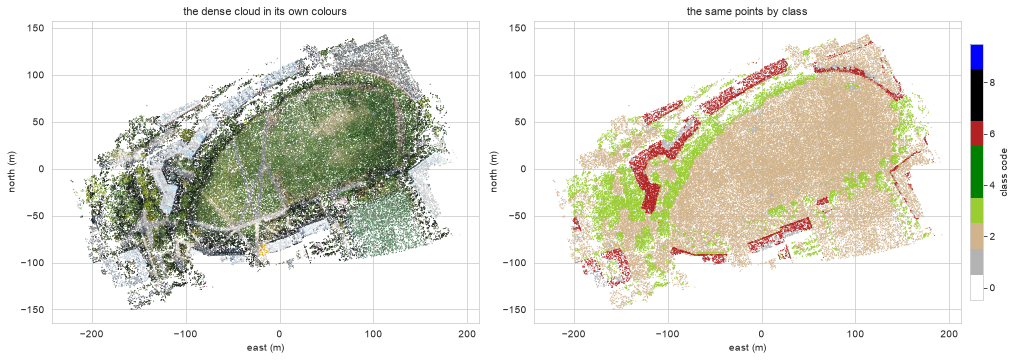

In [2]:
cloud = sfm.load_cloud("data/dense_sample.npz")
sample = reference["whole"]["dense_sample"]
palette = ListedColormap(["w", "0.7", "tan", "yellowgreen", "g", "g", "firebrick", "k", "k", "b"])
print(f"{len(cloud['xyz']):,} points drawn   reference {sample['points']:,}")
print(f"{cloud['n_total']:,} points in the whole cloud   reference {sample['of_total']:,}")
print({int(code): cloud["classes"][code] for code in np.unique(cloud["classification"])})
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
sfm.show_cloud(axes[0], cloud["xyz"], rgb=cloud["rgb"], title="the dense cloud in its own colours")
sfm.show_cloud(axes[1], cloud["xyz"], values=cloud["classification"], cmap=palette, vmin=-0.5,
               vmax=9.5, label="class code", title="the same points by class")

This is a sample of the whole cloud. The left picture is the flight as a photograph made of points. The right picture is what the software later called each point, one colour per class code, and the printed legend says what the codes mean. Look at how the field, the trees and the roofs separate. The sparse cloud of 03b-04 had tens of thousands of points. This one has millions, and every one of them was found by the search of the next section.

## One pixel, one line

The cell picks a point on the roof and a point on the lawn of the window and marks both on the window's surface model.

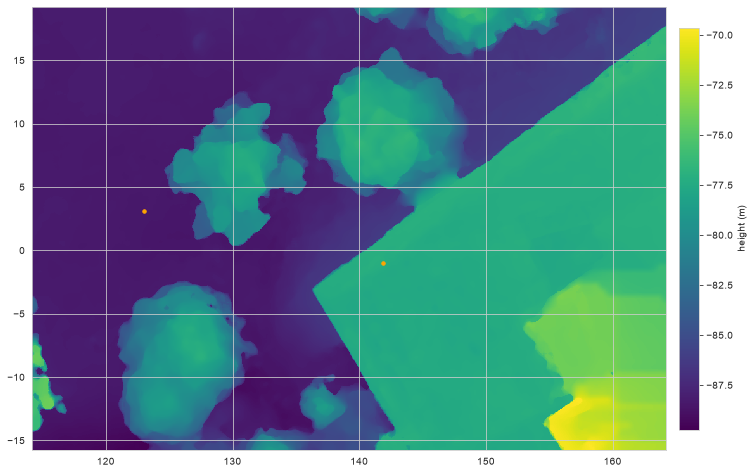

In [3]:
dsm, transform, crs, cell = sfm.read_raster("data/dsm_window.tif")
dtm, _, _, _ = sfm.read_raster("data/dtm_window.tif")
offset = choices["offset"]
centre = choices["window"]["centre_local"]
roof = sfm.roof_mask(sfm.roof_polygon(choices), transform, dsm.shape)
ground = float(np.nanpercentile(dtm, 25))  # the lower quarter of the terrain is the lawn
on_roof = sfm.roof_point(dsm, transform, roof, ground, centre, offset=offset)
surface = sfm.surface_points(dsm, transform, offset)  # one point per metre of the surface model
on_lawn = surface[surface[:, 2] < ground + 0.2].mean(axis=0)  # the middle of the lawn
points = np.array([on_roof, on_lawn])
fig, ax = plt.subplots(figsize=(12, 8))
sfm.show_grid(ax, dsm, transform, offset=offset, label="height (m)", points=points[:, :2] + offset)

The map is the surface model of the window, one height per cell. The roof is the high plateau, the crowns are the round hills, the lawn is the dark floor. The two orange dots are our points. One sits on the roof, a metre in from its edge. The other is the middle of the lawn cells, where every patch looks much like its neighbours. Next we send both points into one photograph through its pose, where the camera stood and how it was turned.

roof (1442, 912) at 62.5 m, lawn (1533, 587) at 73.2 m


array([[36., 36., 38., ..., 33., 34., 35.],
       [39., 40., 39., ..., 35., 35., 35.],
       [39., 38., 38., ..., 35., 36., 34.],
       ...,
       [39., 39., 38., ..., 75., 69., 62.],
       [38., 38., 38., ..., 59., 55., 52.],
       [38., 39., 39., ..., 53., 52., 46.]],
      shape=(200, 200), dtype=float32)

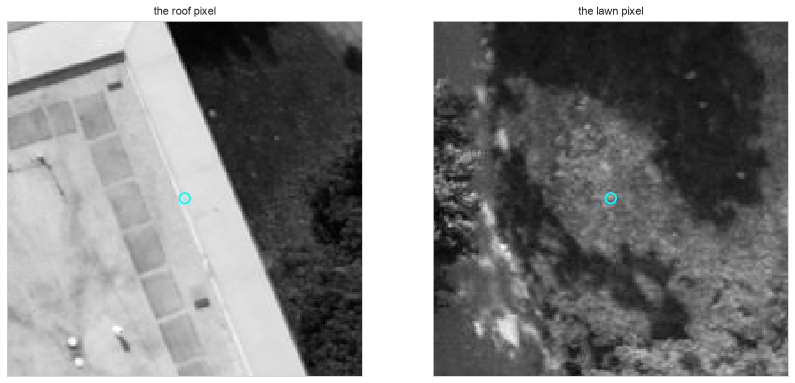

In [4]:
block = sfm.load_block("data/block.npz")
grey_a = sfm.read_image("data/undistorted_a.jpg", gray=True)
grey_b = sfm.read_image("data/undistorted_b.jpg", gray=True)
shots = [choices["photos"]["a"]["shot_index"], choices["photos"]["b"]["shot_index"]]
pose_a, pose_b = zip(block["rotation_map"][shots], block["translation_map"][shots])
pinhole = {"focal_x": block["camera"]["focal_x"]}  # the calibrated focal length, no distortion
u, v, dist = sfm.project_brown(points, *pose_a, pinhole, 2000, 1500)
u, v = np.rint(u).astype(int), np.rint(v).astype(int)  # whole pixels
print(f"roof ({u[0]}, {v[0]}) at {dist[0]:.1f} m, lawn ({u[1]}, {v[1]}) at {dist[1]:.1f} m")
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sfm.crop_at(axes[0], grey_a, u[0], v[0], half=100, title="the roof pixel")
sfm.crop_at(axes[1], grey_a, u[1], v[1], half=100, title="the lawn pixel")

The pair is the two photographs of 03b-03, straightened so that the lens distortion is gone and a pixel is one ray. Each point lands on one pixel, and the print gives its depth, how far along the camera's axis it lies. The roof pixel is nearer than the lawn pixel, by the roof's height. Look at the two patches. The roof pixel sits on the roof's border beside a strong straight edge. The lawn pixel sits in grass with light and shade on it.

roof: peak at 63.11 m, surface model at 62.50 m
lawn: peak at 73.11 m, surface model at 73.23 m


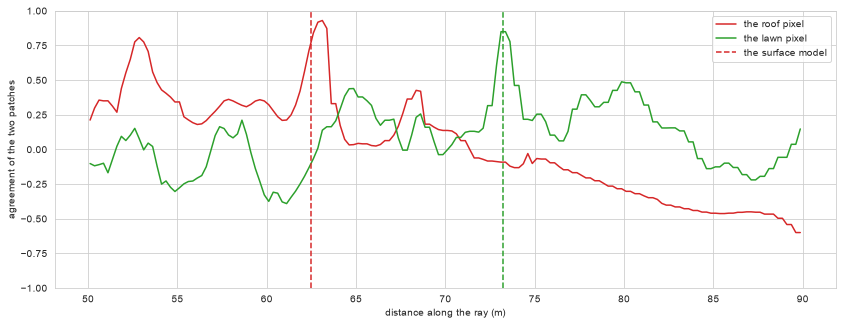

In [5]:
depth_map = sfm.load_depth("data/depth_a.npz")
depths = np.arange(depth_map["dmin"], depth_map["dmax"], choices["depth_step_m"])  # the candidates
ncc_roof = sfm.ncc_depth(grey_a, grey_b, u[0], v[0], pose_a, pose_b, pinhole, 2000, 1500, depths)
ncc_lawn = sfm.ncc_depth(grey_a, grey_b, u[1], v[1], pose_a, pose_b, pinhole, 2000, 1500, depths)
print(f"roof: peak at {depths[np.nanargmax(ncc_roof)]:.2f} m, surface model at {dist[0]:.2f} m")
print(f"lawn: peak at {depths[np.nanargmax(ncc_lawn)]:.2f} m, surface model at {dist[1]:.2f} m")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(depths, ncc_roof, color="tab:red", label="the roof pixel")
ax.plot(depths, ncc_lawn, color="tab:green", label="the lawn pixel")
ax.vlines(dist, -1, 1, colors=["tab:red", "tab:green"], linestyles="--", label="the surface model")
ax.set(xlabel="distance along the ray (m)", ylabel="agreement of the two patches", ylim=(-1, 1))
ax.legend()

A pixel is a ray into space. We step along the ray, project each step into the second photograph, and compare the two patches. One means they agree, zero means they share nothing. Read each curve against its dashed line, where the surface model puts the point. The smaller humps are depths where the ray crossed something that looked alike. The gap between the peak and the humps is the margin the search had. Without texture the humps grow as high as the peak, and the search fails.

## The software's depth map

The cell opens the software's depth map of the same photograph, prints how much of the frame it answered for, and turns the map into a cloud.

76.9% of the pixels have a depth   reference 76.9%
median depth 73.12 m   reference 73.12
4 neighbours   reference 4


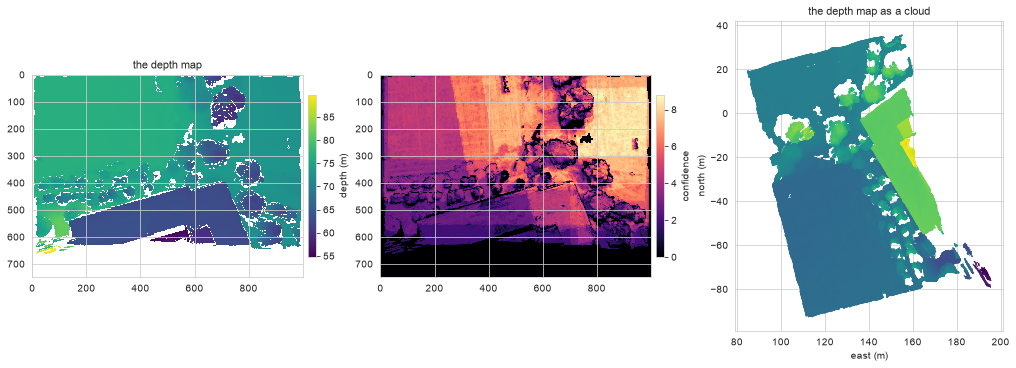

In [6]:
depth = depth_map["depth"]  # metres along the camera's axis, zero where the software found none
valid = depth > 0
expected = reference["depth"]
points_a, _ = sfm.unproject_depth(depth, depth_map["K"], depth_map["R"], depth_map["C"])
print(f"{valid.mean():.1%} of the pixels have a depth   reference {expected['valid_share']:.1%}")
print(f"median depth {np.median(depth[valid]):.2f} m   reference {expected['median_m']}")
print(f"{len(depth_map['neighbours'])} neighbours   reference {len(expected['neighbours'])}")
fig, axes = plt.subplots(1, 3, figsize=(14, 5), layout="constrained")
sfm.show_grid(axes[0], np.where(valid, depth, np.nan), label="depth (m)", title="the depth map")
sfm.show_grid(axes[1], depth_map["confidence"], cmap="magma", label="confidence")
sfm.show_cloud(axes[2], points_a, title="the depth map as a cloud")

The software's answer for this photograph is a depth for most pixels, plus a confidence. The holes are where it gave up. Find them in the left panel and say what lies under them. In the middle panel, the confidence, look where it is dark, on the flat roof and in the shade, where every patch looks like the next. The software did better than our one pair by searching several neighbouring photographs. The right panel is the same depth map as a cloud, one point per pixel.

## The fused cloud in the window

The cell loads the fused cloud of the window, counts its points and their density, and cuts a section one metre wide through the window's centre.

356,691 points in the window   reference 356,691
203.8 points per square metre   reference 203.8
median views per point 3   reference 3


[Text(0.5, 0, 'east (m)'), Text(0, 0.5, 'height (m)'), None, None]

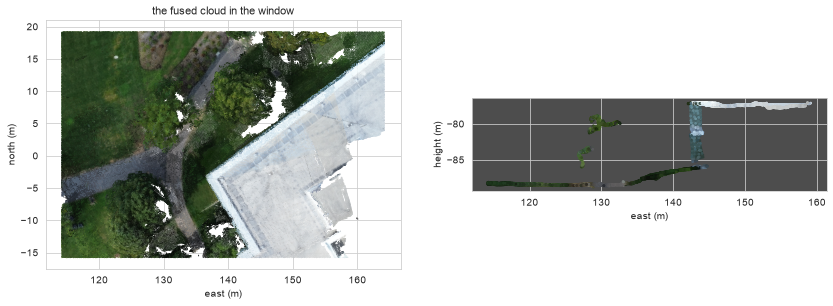

In [7]:
cloud = sfm.load_cloud("data/dense_window.npz")
xyz, views = cloud["xyz"], cloud["views"]  # positions, and how many depth maps saw each point
area = 4 * np.prod(choices["window"]["half_m"])  # square metres
dense = reference["dense"]
print(f"{len(xyz):,} points in the window   reference {dense['points']:,}")
print(f"{sfm.density(xyz, area):.1f} points per square metre   reference {dense['per_m2']}")
print(f"median views per point {np.median(views):.0f}   reference {dense['views']['median']:.0f}")
strip = np.abs(xyz[:, 1] - centre[1]) < 0.5  # one metre wide, west to east through the centre
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_cloud(axes[0], xyz, rgb=cloud["rgb"], title="the fused cloud in the window")
axes[1].scatter(xyz[strip, 0], xyz[strip, 2], c=cloud["rgb"][strip] / 255, s=3)
axes[1].set(xlabel="east (m)", ylabel="height (m)", aspect="equal", facecolor="0.3")

Every depth map becomes a cloud, and the clouds are fused. A point is kept only where at least two maps agree, and its views count how many did. Read the density, the number to remember when you plan a flight. The left picture is the window as the cloud sees it. The right picture is the section, the window cut open from west to east. The lawn is the floor, a crown floats above it, and the roof is the flat line with its wall below it.

## Your turn

The cloud's classes let you measure the density on one kind of surface. The cell counts the one metre cells of the window where most points carry the class code, and the points per square metre on those cells. The codes are in the legend printed at the top. Run the cell as it is, then change the marked value and run it again.

Which surface did the depth maps find easier, the ground or the building, and why? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

In [8]:
CLASS = 2  # change me: 6
cloud = sfm.load_cloud("data/dense_window.npz")
bounds = sfm.window_bounds_local(choices)
cells = sfm.cells_of_class(cloud["xyz"], cloud["classification"], CLASS, bounds)
print(f"{cells.sum()} cells of one square metre are mostly {cloud['classes'][CLASS]}")
print(f"{sfm.density(cloud['xyz'], cells, bounds):.1f} points per square metre on them")

1159 cells of one square metre are mostly ground
182.9 points per square metre on them


## Check your understanding

1. A pixel is a ray. Say why the search for its depth runs along one line in the second photograph, not over the whole picture.
2. Both curves had smaller humps beside their peaks. Say what in a patch lets a hump grow as high as the peak, and name two such surfaces in a town.
3. The depth map carries a confidence for every pixel. Say what the software compares to get it, and why a confident pixel can still be wrong.
4. The fused cloud keeps a point only where two depth maps agree. Say what that rule removes, and what it costs where few photographs looked.

## Where we are

You have run the dense search yourself, a pixel as a ray, the ray as a line of candidates in the second photograph, and the peak of the agreement as the depth. You now know that the software's depth map is that search done for every pixel against several neighbours, that its confidence marks the plain patches, and that the fused cloud keeps only what two maps agreed on. In 03b-06 the cloud becomes a mesh, a surface model and a terrain model.

## Further resources

Nothing in this course requires anything below.

- Stereo Processing by Semiglobal Matching and Mutual Information, Heiko Hirschmüller, IEEE Transactions on Pattern Analysis and Machine Intelligence, 2008: https://elib.dlr.de/55367/
- PatchMatch Stereo: Stereo Matching with Slanted Support Windows, Michael Bleyer, Christoph Rhemann and Carsten Rother, BMVC, 2011: https://www.bmva.org/bmvc/2011/proceedings/paper14/index.html
- Computer Vision: Algorithms and Applications, Richard Szeliski, second edition, 2022, chapter 12 on stereo correspondence: https://szeliski.org/Book/
- OpenMVS, the dense matching library inside OpenDroneMap, cdcseacave and contributors: https://github.com/cdcseacave/openMVS

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0.